# GroundingDINO with OpenVINO™

GroundingDINO is an open-vocabulary object detector that accepts free-text prompts alongside images.

**This notebook:**
1. Loads the SwinT-OGC checkpoint and runs **PyTorch** inference with visual bounding-box output.
2. Converts to **FP32** and **FP16** OpenVINO IRs.
3. Runs FP16 inference on the same test image and compares visually.
4. Runs **INT8** inference (if the pre-quantized model is available).
5. Benchmarks FP16 and INT8 with benchmark_app.

#### Table of contents:
- [Select Device](#Select-Device)
- [Setup](#Setup)
- [Clone Repo + Download Checkpoint](#Clone-and-Download)
- [PyTorch Inference](#PyTorch-Inference)
- [Convert to OpenVINO IR](#Convert)
- [FP16 Inference](#FP16-Inference)
- [Benchmark](#Benchmark)
- [INT8 Inference](#INT8-Inference)

## Prerequisites

Install required packages.

In [1]:
%pip install -q 'openvino>=2025.1.0' 'nncf>=2.16.0' ipywidgets transformers pillow matplotlib scipy --quiet


Note: you may need to restart the kernel to use updated packages.


## Select Device

Pick the OpenVINO inference device. GPU (Intel Arc) appears if the driver is present.

In [2]:
import ipywidgets as widgets
import openvino as ov

_core = ov.Core()
_avail = _core.available_devices
_opts  = [d for d in ["GPU", "CPU", "AUTO"] if d in _avail or d == "CPU"]

device_widget = widgets.Dropdown(
    options=_opts,
    value="GPU" if "GPU" in _opts else "CPU",
    description="Device:",
    style={"description_width": "initial"},
    layout=widgets.Layout(width="300px"),
)
print("Available devices:")
for d in _avail:
    try:
        nm = _core.get_property(d, "FULL_DEVICE_NAME")
        print(f"  {d} -> {nm}")
    except Exception:
        print(f"  {d}")
device_widget


Available devices:
  CPU -> Genuine Intel(R) 0000
  GPU -> Intel(R) Arc(TM) A770 Graphics (dGPU)


Dropdown(description='Device:', layout=Layout(width='300px'), options=('GPU', 'CPU'), style=DescriptionStyle(d…

## Setup

Paths, image shape, detection prompt and IR output locations.

In [3]:
import os, subprocess, sys, re, shutil, time
from pathlib import Path
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np
from PIL import Image

REPO_ROOT = Path.cwd()
if not (REPO_ROOT / "assets").exists() and (REPO_ROOT.parent / "assets").exists():
    REPO_ROOT = REPO_ROOT.parent

GDINO_DIR      = REPO_ROOT / "GroundingDINO"
CHECKPOINT_DIR = REPO_ROOT / "checkpoints"
OUTPUT_DIR     = REPO_ROOT / "outputs"
MODEL_DIR      = REPO_ROOT / "openvino_irs"
CHECKPOINT_DIR.mkdir(exist_ok=True)
OUTPUT_DIR.mkdir(exist_ok=True)

IMAGE_SHAPE   = (384, 384)
SHAPE_NAME    = f"{IMAGE_SHAPE[0]}x{IMAGE_SHAPE[1]}"
TEST_IMAGE    = REPO_ROOT / "assets/test_images/Got7_A.jpg"
TEST_PROMPT   = "Person with white hair"
BOX_THRESH    = 0.30
DEVICE        = device_widget.value

(MODEL_DIR / SHAPE_NAME).mkdir(parents=True, exist_ok=True)
(MODEL_DIR / f"{SHAPE_NAME}_int8").mkdir(parents=True, exist_ok=True)

OV_FP32_XML  = MODEL_DIR / SHAPE_NAME / f"openvino_grounding_dino_{SHAPE_NAME}.xml"
OV_FP16_XML  = MODEL_DIR / SHAPE_NAME / f"openvino_grounding_dino_{SHAPE_NAME}_fp16.xml"
INT8_BS1_XML = MODEL_DIR / f"{SHAPE_NAME}_int8" / f"openvino_grounding_dino_{SHAPE_NAME}_int8_bs1_static.xml"
INT8_DYN_XML = MODEL_DIR / f"{SHAPE_NAME}_int8" / f"openvino_grounding_dino_{SHAPE_NAME}_int8_dynamic.xml"

print(f"Repo root  : {REPO_ROOT}")
print(f"Test image : {TEST_IMAGE}")
print(f"Prompt     : {TEST_PROMPT!r}")
print(f"Device     : {DEVICE}")
print(f"FP32 IR    : {OV_FP32_XML}  (exists={OV_FP32_XML.exists()})")
print(f"FP16 IR    : {OV_FP16_XML}  (exists={OV_FP16_XML.exists()})")
print(f"INT8 BS1   : {INT8_BS1_XML}  (exists={INT8_BS1_XML.exists()})")
print(f"INT8 dyn   : {INT8_DYN_XML}  (exists={INT8_DYN_XML.exists()})")


Repo root  : /home/ubuntu/GroundingDino_OV_repo
Test image : /home/ubuntu/GroundingDino_OV_repo/assets/test_images/Got7_A.jpg
Prompt     : 'Person with white hair'
Device     : GPU
FP32 IR    : /home/ubuntu/GroundingDino_OV_repo/openvino_irs/384x384/openvino_grounding_dino_384x384.xml  (exists=True)
FP16 IR    : /home/ubuntu/GroundingDino_OV_repo/openvino_irs/384x384/openvino_grounding_dino_384x384_fp16.xml  (exists=True)
INT8 BS1   : /home/ubuntu/GroundingDino_OV_repo/openvino_irs/384x384_int8/openvino_grounding_dino_384x384_int8_bs1_static.xml  (exists=True)
INT8 dyn   : /home/ubuntu/GroundingDino_OV_repo/openvino_irs/384x384_int8/openvino_grounding_dino_384x384_int8_dynamic.xml  (exists=True)


## Clone Repo + Download Checkpoint
[back to top ⬆️](#Table-of-contents:)

Uses the OpenVINO-compatible fork . Downloads the SwinT-OGC checkpoint (~660 MB) if not present.

In [4]:
def run_cmd(cmd, cwd=REPO_ROOT):
    print("+", " ".join(str(c) for c in cmd))
    subprocess.run(cmd, cwd=str(cwd), check=True)

if not GDINO_DIR.exists():
    run_cmd(["git", "clone", "https://github.com/wenyi5608/GroundingDINO.git", str(GDINO_DIR)])
sys.path.insert(0, str(GDINO_DIR))
print("GroundingDINO:", GDINO_DIR)

from urllib.request import urlretrieve
CHECKPOINT = CHECKPOINT_DIR / "groundingdino_swint_ogc.pth"
CONFIG     = GDINO_DIR / "groundingdino/config/GroundingDINO_SwinT_OGC.py"
CKPT_URL   = "https://github.com/IDEA-Research/GroundingDINO/releases/download/v0.1.0-alpha/groundingdino_swint_ogc.pth"
if not CHECKPOINT.exists():
    print(f"Downloading checkpoint (~660 MB) ...")
    urlretrieve(CKPT_URL, CHECKPOINT)
print(f"Checkpoint : {CHECKPOINT}")


GroundingDINO: /home/ubuntu/GroundingDino_OV_repo/GroundingDINO
Checkpoint : /home/ubuntu/GroundingDino_OV_repo/checkpoints/groundingdino_swint_ogc.pth


## PyTorch Inference
[back to top ⬆️](#Table-of-contents:)

Load the SwinT-OGC checkpoint, run inference on the test image and visualise detected boxes.

I0000 00:00:1783997598.343319  924910 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1783997598.383073  924910 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI AVX512_BF16 AVX512_FP16 AVX_VNNI AMX_TILE AMX_INT8 AMX_BF16 AMX_FP16 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1783997599.327425  924910 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1783997599.327668  924910 cudart_stub.cc:3

final text_encoder_type: bert-base-uncased
final text_encoder_type: bert-base-uncased


/home/ubuntu/ai-dev/lib/python3.12/site-packages/transformers/modeling_utils.py:1621: FutureWarning: The `device` argument is deprecated and will be removed in v5 of Transformers.
  warnings.warn(
/home/ubuntu/GroundingDino_OV_repo/GroundingDINO/groundingdino/models/GroundingDINO/transformer.py:862: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=False):


PyTorch SwinT-OGC — 1 detection(s) above 0.3:
  score=0.379  cx,cy,w,h=[0.4650000035762787, 0.8320000171661377, 0.38199999928474426, 0.33399999141693115]


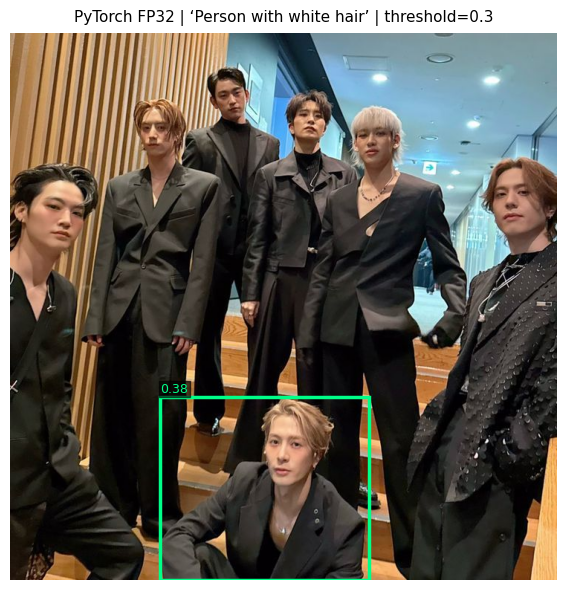

In [5]:
import torch
from groundingdino.models import build_model
from groundingdino.util import get_tokenlizer
from groundingdino.util.slconfig import SLConfig
from groundingdino.util.utils import clean_state_dict
from groundingdino.models.GroundingDINO.bertwarper import generate_masks_with_special_tokens_and_transfer_map
import groundingdino.datasets.transforms as GDT
from torchvision.transforms.functional import InterpolationMode, resize as tv_resize

args_cfg = SLConfig.fromfile(str(CONFIG))
args_cfg.device = "cpu"
args_cfg.use_checkpoint = False
args_cfg.use_transformer_ckpt = False

pt_model = build_model(args_cfg)
pt_model.load_state_dict(clean_state_dict(torch.load(CHECKPOINT, map_location="cpu")["model"]), strict=False)
pt_model.eval()
tokenizer = get_tokenlizer.get_tokenlizer(args_cfg.text_encoder_type)

_gdt = GDT.Compose([GDT.RandomResize([800], max_size=1333), GDT.ToTensor(),
                    GDT.Normalize([0.485,0.456,0.406],[0.229,0.224,0.225])])

def build_inputs(pil_img, caption):
    img_t, _ = _gdt(pil_img.convert("RGB"), None)
    img_t = tv_resize(img_t, list(IMAGE_SHAPE), interpolation=InterpolationMode.BICUBIC)
    cap = caption.lower().strip()
    if not cap.endswith("."): cap += "."
    tok_ = tokenizer([cap], padding="longest", return_tensors="pt")
    sp   = tokenizer.convert_tokens_to_ids(["[CLS]","[SEP]",".","?"])
    tm, pid, _ = generate_masks_with_special_tokens_and_transfer_map(tok_, sp, tokenizer)
    return img_t[None], tok_["input_ids"], tok_["attention_mask"], pid, tok_["token_type_ids"], tm

def sigmoid_np(x):
    x = np.clip(x.astype(np.float32), -88, 88)
    return np.where(x>=0, 1/(1+np.exp(-x)), np.exp(x)/(1+np.exp(x)))

def get_detections(logits, boxes, threshold=BOX_THRESH):
    scores = sigmoid_np(logits).max(-1)
    mask   = scores > threshold
    return boxes[mask], scores[mask]

def show_detections(pil_img, boxes_cx, scores, title=""):
    W_, H_ = pil_img.size
    fig, ax = plt.subplots(figsize=(9,6))
    ax.imshow(pil_img)
    for (cx,cy,w,h), s in zip(boxes_cx, scores):
        x1,y1 = (cx-w/2)*W_, (cy-h/2)*H_
        rect = mpatches.Rectangle((x1,y1), w*W_, h*H_, lw=2.5, ec="#00FF88", fc="none")
        ax.add_patch(rect)
        ax.text(x1, y1-6, f"{s:.2f}", color="#00FF88", fontsize=9,
                bbox=dict(fc="black", alpha=0.6, pad=1))
    ax.axis("off")
    ax.set_title(title, fontsize=11, pad=8)
    plt.tight_layout(); plt.show()

# Run PyTorch inference
pil_img = Image.open(TEST_IMAGE)
img_t, ids, amask, pid, ttids, tm = build_inputs(pil_img, TEST_PROMPT)

with torch.no_grad():
    pt_out = pt_model(img_t, ids, amask, pid, ttids, tm)

pt_boxes, pt_scores = get_detections(
    pt_out["pred_logits"][0].numpy(), pt_out["pred_boxes"][0].numpy())

print(f"PyTorch SwinT-OGC — {len(pt_boxes)} detection(s) above {BOX_THRESH}:")
for b,s in zip(pt_boxes, pt_scores):
    print(f"  score={s:.3f}  cx,cy,w,h={b.round(3).tolist()}")

show_detections(pil_img, pt_boxes, pt_scores,
    title=f"PyTorch FP32 | ‘{TEST_PROMPT}’ | threshold={BOX_THRESH}")


## Convert to OpenVINO IR
[back to top ⬆️](#Table-of-contents:)

Traces the model with  then calls . Both **FP32** (full precision) and **FP16** (weight-compressed) IRs are saved. Conversion is cache-aware.

In [6]:
H_, W_ = IMAGE_SHAPE
tok_d = tokenizer(["the running dog ."], return_tensors="pt")
ids_d, ttids_d, amask_d = tok_d["input_ids"], tok_d["token_type_ids"], tok_d["attention_mask"]
pid_d = torch.arange(ids_d.shape[1]).reshape(1,-1)
tm_d  = torch.randint(0, 2, (1, ids_d.shape[1], ids_d.shape[1]), dtype=torch.bool)
dummy = (torch.randn(1,3,H_,W_), ids_d, amask_d, pid_d, ttids_d, tm_d)

for p in pt_model.parameters(): p.requires_grad_(False)

if not OV_FP32_XML.exists():
    print("Converting to FP32 IR (this may take a few minutes) ...")
    with torch.no_grad():
        traced = torch.jit.trace(pt_model, example_inputs=dummy, strict=False, check_trace=False)
    ov_mod = ov.convert_model(traced, example_input=dummy)
    ov.save_model(ov_mod, OV_FP32_XML, compress_to_fp16=False)
    print(f"  Saved FP32: {OV_FP32_XML.name}  ({OV_FP32_XML.with_suffix(".bin").stat().st_size/1e6:.0f} MB)")
else:
    print(f"Reusing FP32 IR: {OV_FP32_XML.name}  ({OV_FP32_XML.with_suffix(".bin").stat().st_size/1e6:.0f} MB)")

if not OV_FP16_XML.exists():
    print("Saving FP16 IR (weight compression from FP32) ...")
    core_tmp = ov.Core()
    m_fp32 = core_tmp.read_model(OV_FP32_XML)
    ov.save_model(m_fp32, OV_FP16_XML, compress_to_fp16=True)
    print(f"  Saved FP16: {OV_FP16_XML.name}  ({OV_FP16_XML.with_suffix(".bin").stat().st_size/1e6:.0f} MB)")
else:
    print(f"Reusing FP16 IR: {OV_FP16_XML.name}  ({OV_FP16_XML.with_suffix(".bin").stat().st_size/1e6:.0f} MB)")


Reusing FP32 IR: openvino_grounding_dino_384x384.xml  (345 MB)
Reusing FP16 IR: openvino_grounding_dino_384x384_fp16.xml  (345 MB)


## FP16 Inference
[back to top ⬆️](#Table-of-contents:)

Compile the FP16 IR on the selected device and run inference on the test image.

Compiling FP16 IR on GPU ...
  in  samples                        [?,?,?,?]
  in  input_ids                      [?,?]
  in  attention_mask.1               [?,?]
  in  position_ids                   [?,?]
  in  token_type_ids                 [?,?]
  in  401                            [?,?,?]
  out pred_logits                    [?,900,256]
  out pred_boxes                     [?,900,4]
✓ FP16 compiled on GPU
FP16 (GPU): 1 detection(s) in 1895.7 ms
  score=0.36  cx,cy,w,h=[0.4650000035762787, 0.8330000042915344, 0.38100001215934753, 0.3330000042915344]


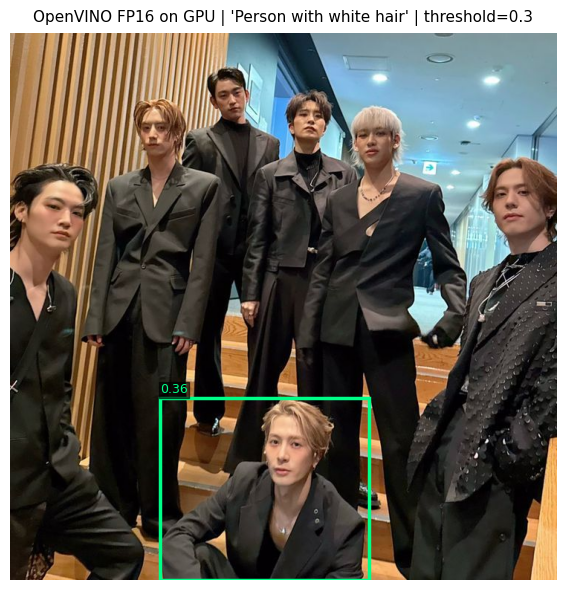

In [7]:
core = ov.Core()

def _compile_print(xml, device):
    m = core.read_model(xml)
    for i, p in enumerate(m.inputs):
        ns    = p.get_names()
        pname = next(iter(ns)) if ns else ("in_" + str(i))
        print("  in  " + pname.ljust(30) + " " + str(p.get_partial_shape()))
    for i, p in enumerate(m.outputs):
        ns    = p.get_names()
        pname = next(iter(ns)) if ns else ("out_" + str(i))
        print("  out " + pname.ljust(30) + " " + str(p.get_partial_shape()))
    return core.compile_model(m, device)

print("Compiling FP16 IR on " + DEVICE + " ...")
fp16_compiled = _compile_print(OV_FP16_XML, DEVICE)
print("\u2713 FP16 compiled on " + DEVICE)

def ov_infer(compiled, pil_img, caption, threshold=BOX_THRESH):
    img_t, ids, amask, pid, ttids, tm = build_inputs(pil_img, caption)
    inp = {
        "samples":                   img_t.numpy().astype(np.float32),
        "input_ids":                 ids.numpy(),
        "attention_mask.1":          amask.numpy(),
        "position_ids":              pid.numpy(),
        "token_type_ids":            ttids.numpy(),
        "text_self_attention_masks": tm.numpy(),
    }
    out = compiled(inp)
    return get_detections(out["pred_logits"][0], out["pred_boxes"][0], threshold)

t0 = time.perf_counter()
fp16_boxes, fp16_scores = ov_infer(fp16_compiled, pil_img, TEST_PROMPT)
fp16_lat_ms = (time.perf_counter() - t0) * 1000

n_dets = len(fp16_boxes)
print("FP16 (" + DEVICE + "): " + str(n_dets) + " detection(s) in " + str(round(fp16_lat_ms, 1)) + " ms")
for b, s in zip(fp16_boxes, fp16_scores):
    print("  score=" + str(round(float(s), 3)) + "  cx,cy,w,h=" + str(b.round(3).tolist()))

show_detections(pil_img, fp16_boxes, fp16_scores,
    title="OpenVINO FP16 on " + DEVICE + " | '" + TEST_PROMPT + "' | threshold=" + str(BOX_THRESH))


## Benchmark
[back to top ⬆️](#Table-of-contents:)

 runs in latency/sync mode for 30 s. FP16 and INT8 (if available) are both measured.

In [10]:
BENCH_SEC = int(os.environ.get("BENCHMARK_SECONDS", "30"))
_bench = shutil.which("benchmark_app")
if _bench is None:
    raise FileNotFoundError("benchmark_app not found on PATH.")

H_, W_ = IMAGE_SHAPE
_ds = (
    "samples[1,3," + str(H_) + "," + str(W_) + "],"
    "input_ids[1,6],"
    "attention_mask.1[1,6],"
    "position_ids[1,6],"
    "token_type_ids[1,6],"
    "text_self_attention_masks[1,6,6]"
)

bench_results = {}

def _run_bench_on(xml, label, device):
    cmd = [_bench, "-m", str(xml), "-d", device,
           "-data_shape", _ds,
           "-hint", "latency", "-api", "sync", "-t", str(BENCH_SEC)]
    print("\n" + "-"*60 + "\n  " + label + "  [" + device + "]")
    proc = subprocess.run(cmd, text=True, stdout=subprocess.PIPE, stderr=subprocess.STDOUT)
    last = proc.stdout[-800:]
    print(last)
    fps_m = re.search(r"Throughput:\s*([0-9.]+)\s*FPS", proc.stdout)
    lat_m = re.search(r"Average:\s*([0-9.]+)\s*ms",     proc.stdout)
    fps = float(fps_m.group(1)) if fps_m else None
    lat = float(lat_m.group(1)) if lat_m else None
    print("  => latency=" + str(lat) + " ms  FPS=" + str(fps))
    return fps, lat

# FP16 on selected device
fps, lat = _run_bench_on(OV_FP16_XML, "FP16 " + SHAPE_NAME, DEVICE)
bench_results["FP16 " + SHAPE_NAME + " [" + DEVICE + "]"] = {"fps": fps, "latency_ms": lat}

# INT8 — try GPU first, fall back to CPU
_int8_done = False
for _cand in [INT8_DYN_XML, INT8_BS1_XML]:
    if not _cand.exists():
        continue
    for _dev in [DEVICE, "CPU"]:
        fps, lat = _run_bench_on(_cand, "INT8 " + _cand.stem, _dev)
        if fps is not None:
            bench_results["INT8 " + _cand.stem[:25] + " [" + _dev + "]"] = {"fps": fps, "latency_ms": lat}
            _int8_done = True
            break
        print("  [" + _dev + "] failed — trying next")
    if _int8_done:
        break

if not _int8_done:
    print("[INFO] No INT8 variant benchmarked successfully on any device.")

# Summary
sep = "=" * 64
div = "-" * 64
print("\n" + sep)
print("  Benchmark Summary | " + str(BENCH_SEC) + "s latency/sync")
print(div)
print("  " + "Model".ljust(38) + " " + "Latency ms".rjust(12) + " " + "FPS".rjust(10))
print(div)
for k, v in bench_results.items():
    lat_s = str(round(v["latency_ms"], 2)) if v["latency_ms"] else "N/A"
    fps_s = str(round(v["fps"], 2))        if v["fps"]        else "N/A"
    print("  " + k.ljust(38) + " " + lat_s.rjust(12) + " " + fps_s.rjust(10))
print(sep)



------------------------------------------------------------
  FP16 384x384  [GPU]


m values 
[ INFO ] Fill input 'attention_mask.1' with random values 
[ INFO ] Fill input 'position_ids' with random values 
[ INFO ] Fill input 'token_type_ids' with random values 
[ INFO ] Fill input '401' with random values 
[Step 10/11] Measuring performance (Start inference synchronously, limits: 30000 ms duration)
[ INFO ] Benchmarking in full mode (inputs filling are included in measurement loop).
[ INFO ] First inference took 1870.21 ms
[Step 11/11] Dumping statistics report
[ INFO ] Execution Devices:['GPU.0']
[ INFO ] Count:            578 iterations
[ INFO ] Duration:         30009.23 ms
[ INFO ] Latency:
[ INFO ]    Median:        51.53 ms
[ INFO ]    Average:       51.69 ms
[ INFO ]    Min:           50.52 ms
[ INFO ]    Max:           56.46 ms
[ INFO ] Throughput:   19.26 FPS

  => latency=51.69 ms  FPS=19.26

------------------------------------------------------------
  INT8 openvino_grounding_dino_384x384_int8_dynamic  [GPU]
 recent call last):
  File "/home/ubuntu/ai-d

## INT8 Inference
[back to top ⬆️](#Table-of-contents:)

Runs INT8 inference when the accuracy-aware quantized model is available. Shows a side-by-side FP16 vs INT8 comparison.

Found: openvino_grounding_dino_384x384_int8_dynamic.xml
✓ INT8 compiled and verified on CPU
INT8 (CPU): 0 det in 157.2 ms


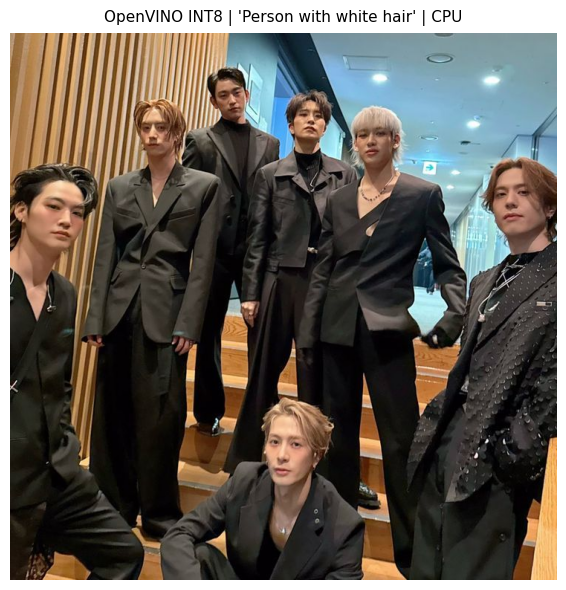

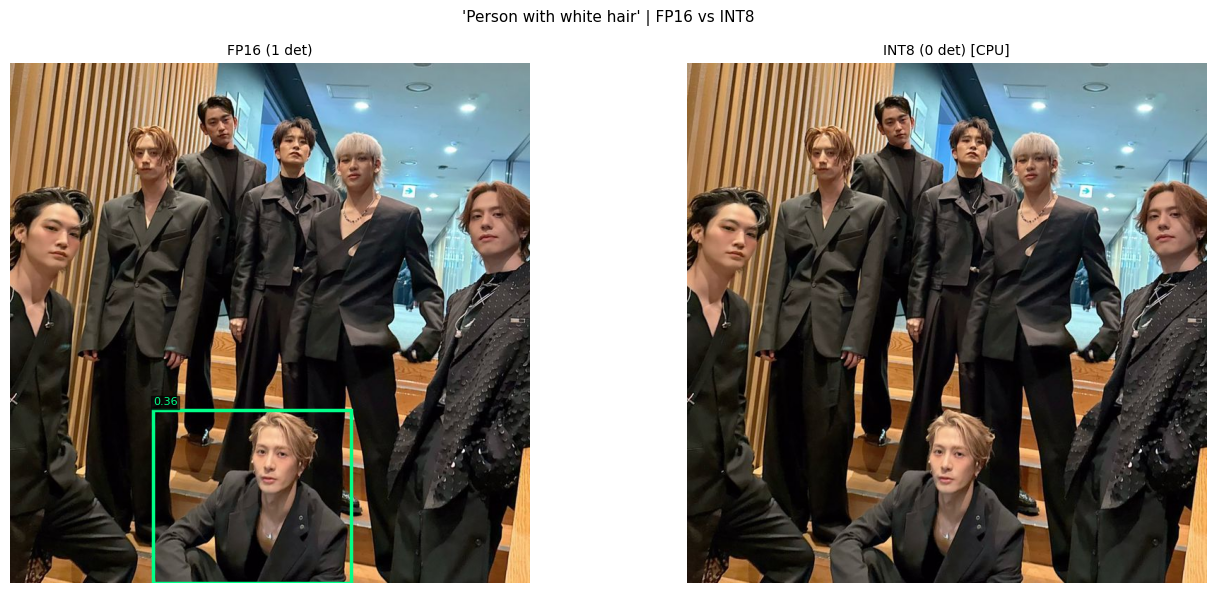


  Precision      Device             Latency ms   Dets
--------------------------------------------------------------
  PyTorch FP32   CPU             N/A (PT)      1
  OV FP16        GPU                   1895.7     1
  OV INT8        CPU                    157.2     0


In [12]:
# ── INT8 Inference ────────────────────────────────────────────────────────
# NOTE: The INT8 GDINO models have a known OV 2026.2 GPU issue:
#   - dynamic:   compiles on GPU but fails at first inference (clBuildProgram)
#   - bs1_static: reshape/reduce axis error on both GPU and CPU
# The dynamic model runs correctly on CPU. CPU is used directly here.
# ─────────────────────────────────────────────────────────────────────────

_int8_candidates = [INT8_DYN_XML, INT8_BS1_XML]
_int8_path = next((x for x in _int8_candidates if x.exists()), None)

if _int8_path is None:
    print("=" * 60)
    print("  INT8 model not found.")
    for _c in _int8_candidates:
        print("    " + str(_c) + "  [missing]")
    print("=" * 60)
else:
    print("Found: " + _int8_path.name)
    # Dynamic INT8 runs on CPU; GPU fails at kernel build during inference.
    # Use CPU directly instead of attempting GPU and handling a lazy failure.
    _int8_cm  = None
    _int8_dev = None

    if _int8_path == INT8_DYN_XML:
        # Dynamic model: CPU only (GPU fails at inference time)
        _devices_to_try = ["CPU"]
    else:
        # BS1 static: try both (though both currently fail)
        _devices_to_try = [DEVICE, "CPU"]

    for _dev in _devices_to_try:
        try:
            _int8_cm  = core.compile_model(_int8_path, _dev)
            # Quick smoke-test inference before committing
            _test_inp = ov_infer(_int8_cm, pil_img, TEST_PROMPT)
            _int8_dev = _dev
            print("\u2713 INT8 compiled and verified on " + _dev)
            # Re-assign the returned boxes
            _int8_b, _int8_s = _test_inp
            break
        except RuntimeError as _e:
            print("  [" + _dev + "] failed (" + type(_e).__name__ + ") -- " + str(_e)[:100])
            _int8_cm = None

    if _int8_cm is None:
        print()
        print("INT8 inference could not run on any device.")
        print("Known limitation: OV 2026.2 GPU clBuildProgram error on INT8 GDINO models.")
    else:
        _t0 = time.perf_counter()
        _int8_b, _int8_s = ov_infer(_int8_cm, pil_img, TEST_PROMPT)
        _int8_lat = (time.perf_counter() - _t0) * 1000

        print("INT8 (" + _int8_dev + "): " + str(len(_int8_b)) + " det in " + str(round(_int8_lat,1)) + " ms")
        for _b, _s in zip(_int8_b, _int8_s):
            print("  score=" + str(round(float(_s),3)) + "  " + str(_b.round(3).tolist()))

        show_detections(pil_img, _int8_b, _int8_s,
            title="OpenVINO INT8 | '" + TEST_PROMPT + "' | " + _int8_dev)

        import matplotlib.patches as _mp
        _fig, _axes = plt.subplots(1, 2, figsize=(14, 6))
        for _ax, _bxs, _scs, _lbl in zip(
            _axes,
            [fp16_boxes, _int8_b],
            [fp16_scores, _int8_s],
            ["FP16 (" + str(len(fp16_boxes)) + " det)",
             "INT8 (" + str(len(_int8_b)) + " det) [" + _int8_dev + "]"]
        ):
            _W, _H = pil_img.size
            _ax.imshow(pil_img)
            for (_cx,_cy,_w,_h), _s in zip(_bxs, _scs):
                _x1,_y1=(_cx-_w/2)*_W,(_cy-_h/2)*_H
                _ax.add_patch(_mp.Rectangle((_x1,_y1),_w*_W,_h*_H,lw=2.5,ec="#00FF88",fc="none"))
                _ax.text(_x1,_y1-6,str(round(float(_s),2)),color="#00FF88",fontsize=8,
                         bbox=dict(fc="black",alpha=0.6,pad=1))
            _ax.axis("off"); _ax.set_title(_lbl, fontsize=10)
        _fig.suptitle("'" + TEST_PROMPT + "' | FP16 vs INT8", fontsize=11)
        plt.tight_layout(); plt.show()

        _sep = "=" * 62
        _div = "-" * 62
        print("\n" + _sep)
        print("  " + "Precision".ljust(14) + " " + "Device".ljust(16) +
              " " + "Latency ms".rjust(12) + " " + "Dets".rjust(6))
        print(_div)
        print("  PyTorch FP32   CPU             N/A (PT)      " + str(len(pt_boxes)))
        print("  OV FP16        " + DEVICE.ljust(16) + str(round(fp16_lat_ms,1)).rjust(12) + str(len(fp16_boxes)).rjust(6))
        print("  OV INT8        " + _int8_dev.ljust(16) + str(round(_int8_lat,1)).rjust(12) + str(len(_int8_b)).rjust(6))
        print(_sep)
